In [2]:

#%% Run to have everything 

import torch
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../tgv_pycuda-master"))
sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))




from Algo_setuptorch import Params

from data.dataset import build_train_test_data


from algorithm.unrolled_model import UnrolledFBS
from training.train import train
from NN.plots import *
from NN.run import *


from denoise_pycuda import tgv_denoise

from pghd_denoising import pdhg






device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

params = Params()

TRAIN_SEEDS = list(range(50))  
TEST_SEEDS = list(range(50,60))


size = params.size
SHAPES = [
    (1, 1, size, size),
    (1, 2, size, size),
    (1, 2, size, size),
    (1, 3, size, size),
]
N_CH = sum(s[1] for s in SHAPES)
N_CH_primal = sum(s[1] for s in SHAPES[:2])
print("ok")

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)


initial_state, clean, functions = test_data[0]

Device: cuda
ok


In [3]:

model = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=10,
    alpha=0.99,
).to(device).float()

model.load_state_dict(torch.load("model_nosafe_20.pt", map_location="cpu"))

model.eval()
 

UnrolledFBS(
  (dev_net): DeviationNet(
    (input_norm): InstanceNorm2d(21, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (body): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(21, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
      (1): ConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
    )
    (final): Conv2d(32, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [4]:
AxCx, res_0= run_zero(initial_state,functions, params, SHAPES, 500, device)
last = AxCx[-1]
print(last)


iter:0
iter:1
iter:2
iter:3
iter:4
iter:5
iter:6
iter:7
iter:8
iter:9
iter:10
iter:11
iter:12
iter:13
iter:14
iter:15
iter:16
iter:17
iter:18
iter:19
iter:20
iter:21
iter:22
iter:23
iter:24
iter:25
iter:26
iter:27
iter:28
iter:29
iter:30
iter:31
iter:32
iter:33
iter:34
iter:35
iter:36
iter:37
iter:38
iter:39
iter:40
iter:41
iter:42
iter:43
iter:44
iter:45
iter:46
iter:47
iter:48
iter:49
iter:50
iter:51
iter:52
iter:53
iter:54
iter:55
iter:56
iter:57
iter:58
iter:59
iter:60
iter:61
iter:62
iter:63
iter:64
iter:65
iter:66
iter:67
iter:68
iter:69
iter:70
iter:71
iter:72
iter:73
iter:74
iter:75
iter:76
iter:77
iter:78
iter:79
iter:80
iter:81
iter:82
iter:83
iter:84
iter:85
iter:86
iter:87
iter:88
iter:89
iter:90
iter:91
iter:92
iter:93
iter:94
iter:95
iter:96
iter:97
iter:98
iter:99
iter:100
iter:101
iter:102
iter:103
iter:104
iter:105
iter:106
iter:107
iter:108
iter:109
iter:110
iter:111
iter:112
iter:113
iter:114
iter:115
iter:116
iter:117
iter:118
iter:119
iter:120
iter:121
iter:122
ite

In [ ]:
F_vals_0, res_0= run_zero(initial_state,functions, params, SHAPES, 1000, device)
F_vals,res ,history= run_learned(model,initial_state,clean,functions,T_test=1000,return_all=True)
import matplotlib.pyplot as plt
print(F_vals)


iter:0
iter:1


iter:2
iter:3
iter:4
iter:5
iter:6
iter:7
iter:8
iter:9
iter:10
iter:11
iter:12
iter:13
iter:14
iter:15
iter:16
iter:17
iter:18
iter:19
iter:20
iter:21
iter:22
iter:23
iter:24
iter:25
iter:26
iter:27
iter:28
iter:29
iter:30
iter:31
iter:32
iter:33
iter:34
iter:35
iter:36
iter:37
iter:38
iter:39
iter:40
iter:41
iter:42
iter:43
iter:44
iter:45
iter:46
iter:47
iter:48
iter:49
iter:50
iter:51
iter:52
iter:53
iter:54
iter:55
iter:56
iter:57
iter:58
iter:59
iter:60
iter:61
iter:62
iter:63
iter:64
iter:65
iter:66
iter:67
iter:68
iter:69
iter:70
iter:71
iter:72
iter:73
iter:74
iter:75
iter:76
iter:77
iter:78
iter:79
iter:80
iter:81
iter:82
iter:83
iter:84
iter:85
iter:86
iter:87
iter:88
iter:89
iter:90
iter:91
iter:92
iter:93
iter:94
iter:95
iter:96
iter:97
iter:98
iter:99
iter:0
iter:1
iter:2
iter:3
iter:4
iter:5
iter:6
iter:7
iter:8
iter:9
iter:10
iter:11
iter:12
iter:13
iter:14
iter:15
iter:16
iter:17
iter:18
iter:19
iter:20
iter:21
iter:22
iter:23
iter:24
iter:25
iter:26
iter:27
iter:28
it

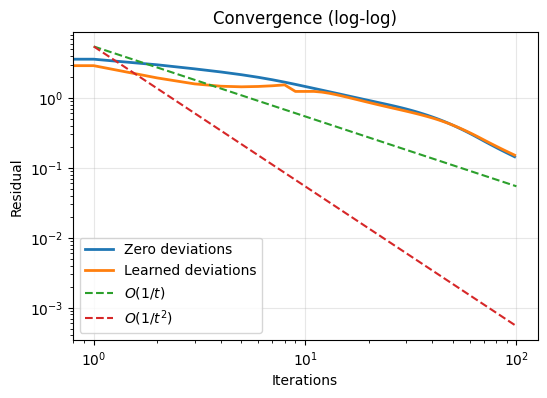

In [6]:

# Convertir en numpy si besoin
res_0 = np.array(res_0)
res = np.array(res)

# Axe des itérations 
iters = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6,4))

# Courbes principales

plt.loglog(res_0[1:], label='Zero deviations', linewidth=2)
plt.loglog(res[1:], label='Learned deviations', linewidth=2)
# Références théoriques
plt.loglog(iters, res_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, res_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

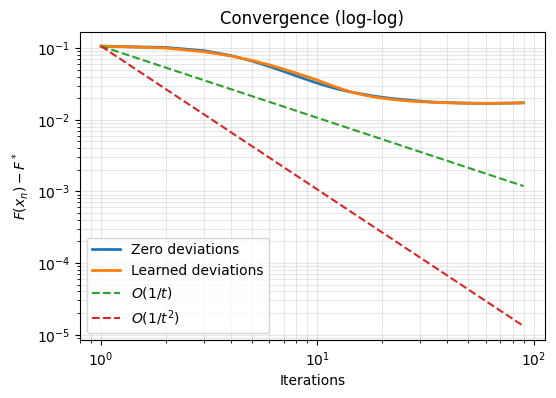

In [7]:
# convertir proprement
F_vals_0 = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_0
])

F_vals = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals
])

# approx de F*


# gaps
gap_0 = F_vals_0
gap   = F_vals

# éviter log(0)
gap_0 = np.maximum(gap_0, 1e-16)
gap   = np.maximum(gap,   1e-16)

gap_0 = gap_0[:90]
gap   =gap[:90]


iters = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6,4))

plt.loglog(iters, gap_0, label='Zero deviations', linewidth=2)
plt.loglog(iters, gap,   label='Learned deviations', linewidth=2)

# références
plt.loglog(iters, gap_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, gap_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel(r'$F(x_n) - F^*$')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

In [8]:

data = initial_state.detach().cpu().squeeze().numpy()

x, F_vals_pdhg = pdhg(data)

F_vals_learned,res_learned = run_learned(model,initial_state,clean,functions,T_test=500)

gaps = np.array(F_vals_pdhg) - min(F_vals_pdhg)
gaps_learned = np.array(F_vals_learned) - min(F_vals_learned)

gaps=gaps[:1000]
gaps_learned=gaps_learned[:1000]

iter = 0
Iter 1: F(x) = 133.926874
iter = 1
Iter 2: F(x) = 132.093462
iter = 2
Iter 3: F(x) = 129.108241
iter = 3
Iter 4: F(x) = 125.229963
iter = 4
Iter 5: F(x) = 120.768247
iter = 5
Iter 6: F(x) = 116.016217
iter = 6
Iter 7: F(x) = 111.196290
iter = 7
Iter 8: F(x) = 106.347796
iter = 8
Iter 9: F(x) = 101.490231
iter = 9
Iter 10: F(x) = 96.695774
iter = 10
Iter 11: F(x) = 92.051195
iter = 11
Iter 12: F(x) = 87.656128
iter = 12
Iter 13: F(x) = 83.597443
iter = 13
Iter 14: F(x) = 79.907212
iter = 14
Iter 15: F(x) = 76.623346
iter = 15
Iter 16: F(x) = 73.787363
iter = 16
Iter 17: F(x) = 71.428428
iter = 17
Iter 18: F(x) = 69.548160
iter = 18
Iter 19: F(x) = 68.137704
iter = 19
Iter 20: F(x) = 67.182328
iter = 20
Iter 21: F(x) = 66.649403
iter = 21
Iter 22: F(x) = 66.485458
iter = 22
Iter 23: F(x) = 66.633845
iter = 23
Iter 24: F(x) = 67.033143
iter = 24
Iter 25: F(x) = 67.629735
iter = 25
Iter 26: F(x) = 68.367192
iter = 26
Iter 27: F(x) = 69.187855
iter = 27
Iter 28: F(x) = 70.043356
it

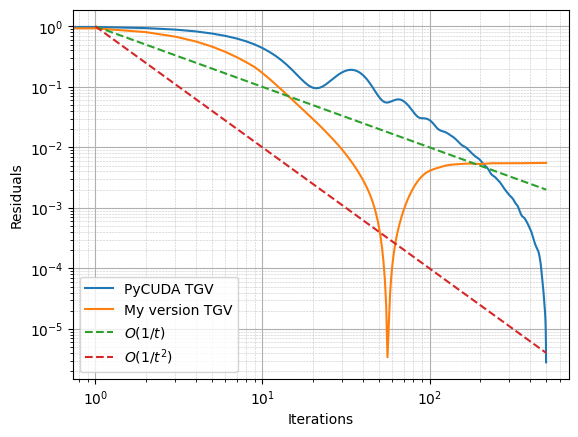

In [9]:

gaps = gaps[gaps > 1e-12]
gaps_learned = gaps_learned[gaps_learned > 1e-12]
gaps /= gaps[0]
gaps_learned /= gaps_learned[0]
N = min(len(gaps), len(gaps_learned))
t = np.arange(1, N + 1)

plt.loglog(gaps[:N], label="PyCUDA TGV")
plt.loglog(gaps_learned[:N], label="My version TGV")




ref1 = 1/ t         # O(1/t)
ref2 = 1 / (t**2)    # O(1/t^2)

plt.loglog(t, ref1, '--', label=r'$O(1/t)$')
plt.loglog(t, ref2, '--', label=r'$O(1/t^2)$') 

plt.xlabel("Iterations")
plt.ylabel("Residuals")
plt.legend()
plt.minorticks_on()  # active les sous-graduations
plt.grid(which='major', linestyle='-', linewidth=0.8)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.7)

plt.savefig("energy.pdf")
plt.show()  